# Feature Engineering: CTR Impact Features
By Yusuf


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def safe_divide(a, b):
    return a / b.replace(0, np.nan)


## Load Data


In [2]:
df = pd.read_csv('../../data_raw_fix/Data_Merged_Fix.csv')

# Standardize columns to match the previous structure
rename_dict = {
    'Video title': 'video_title',
    'Duration': 'duration',
    'Average percentage viewed (%)': 'average_percentage_viewed_pct',
    'Engaged views': 'engaged_views',
    'YouTube Premium (IDR)': 'youtube_premium_idr',
    'Watch Page ads (IDR)': 'watch_page_ads_idr',
    'Estimated AdSense revenue (IDR)': 'estimated_adsense_revenue_idr',
    'YouTube ad revenue (IDR)': 'youtube_ad_revenue_idr',
    'Ad impressions': 'ad_impressions',
    'Playback-based CPM (IDR)': 'playback_based_cpm_idr',
    'CPM (IDR)': 'cpm_idr',
    'Estimated monetized playbacks': 'estimated_monetized_playbacks',
    'RPM (IDR)': 'rpm_idr',
    'Views': 'views',
    'Watch time (hours)': 'watch_time_hours',
    'Subscribers': 'subscribers',
    'Estimated revenue (IDR)': 'estimated_revenue_idr',
    'Impressions': 'impressions',
    'Impressions click-through rate (%)': 'impressions_click_through_rate_pct',
    'Video_ID': 'video_id',
    'TS1_Views': 'ts1_views',
    'TS2_Views': 'ts2_views',
    'TS3_Views': 'ts3_views',
    'TS4_Views': 'ts4_views',
    'Publish_Date_WIB': 'publish_date',
    'Publish_Time_WIB': 'publish_time_wib'
}
df = df.rename(columns=rename_dict)

# Fix missing columns that cause KeyErrors
if 'likes' not in df.columns:
    df['likes'] = df.get('Reactions', 0)
if 'comments' not in df.columns:
    df['comments'] = df.get('Chat messages', 0)
if 'video_duration_sec' not in df.columns:
    df['video_duration_sec'] = df.get('duration', df.get('Duration', 1))


import numpy as np
def parse_duration_to_seconds(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    parts = str(val).strip().split(':')
    try:
        parts = [int(p) for p in parts]
        if len(parts) == 3: return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2: return parts[0] * 60 + parts[1]
        return float(parts[0])
    except: return np.nan

if 'Average view duration' in df.columns:
    df['avg_view_duration_sec'] = df['Average view duration'].apply(parse_duration_to_seconds)
    
if 'publish_date' in df.columns:
    df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')



## 1. impression_to_view_rate
views / impressions


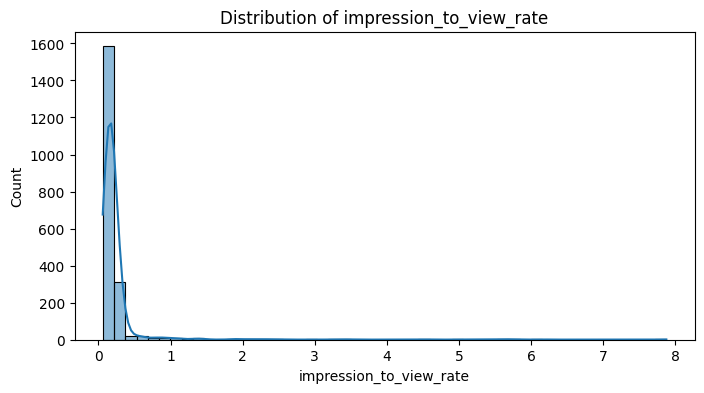

In [3]:
df['impression_to_view_rate'] = safe_divide(df['views'], df['impressions']).fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['impression_to_view_rate'], bins=50, kde=True)
plt.title('Distribution of impression_to_view_rate')
plt.show()


## 2. ctr_normalized
ctr / 100 (and clip to 0-1)


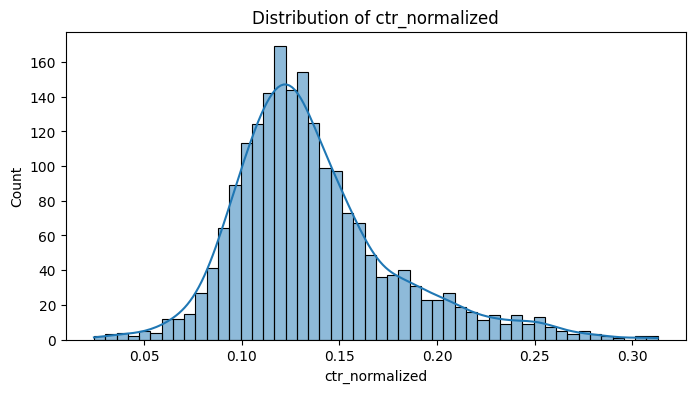

In [4]:
if 'ctr' not in df.columns:
    df['ctr'] = df['impressions_click_through_rate_pct']

df['ctr_normalized'] = (df['ctr'] / 100).clip(0, 1)

plt.figure(figsize=(8,4))
sns.histplot(df['ctr_normalized'], bins=50, kde=True)
plt.title('Distribution of ctr_normalized')
plt.show()


## 3. ctr_impression_score
ctr_normalized * impression_to_view_rate


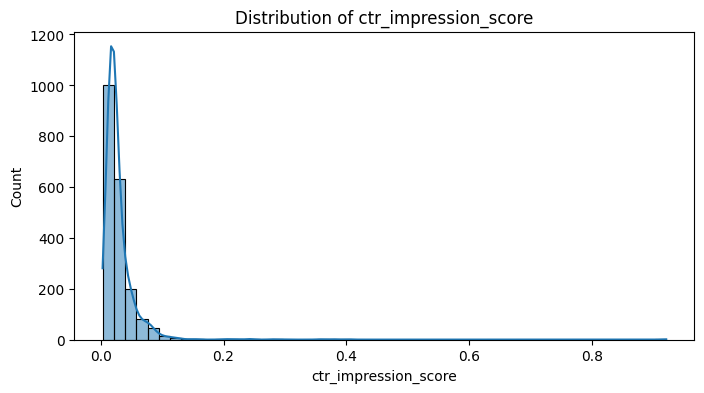

In [5]:
df['ctr_impression_score'] = df['ctr_normalized'] * df['impression_to_view_rate']

plt.figure(figsize=(8,4))
sns.histplot(df['ctr_impression_score'], bins=50, kde=True)
plt.title('Distribution of ctr_impression_score')
plt.show()


## 4. ctr_category & CTR Category Analysis
Bin CTR into Low(<3%), Mid(3-7%), High(>7%)


ctr_category
High    1946
Mid       40
Low        2
Name: count, dtype: int64


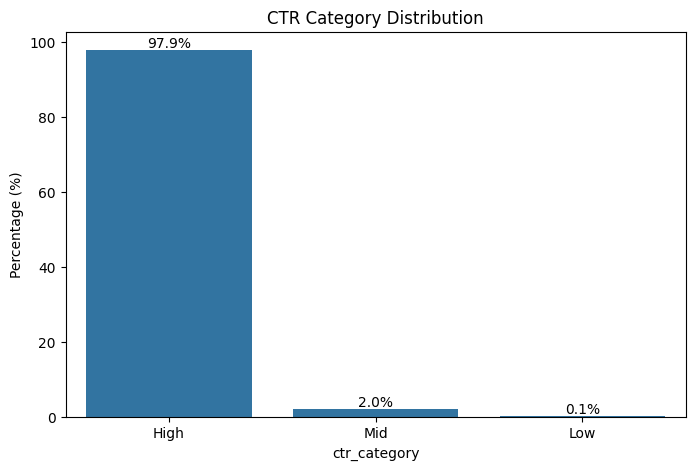

In [6]:
def categorize_ctr(x):
    if x < 3:
        return 'Low'
    elif x <= 7:
        return 'Mid'
    else:
        return 'High'

df['ctr_category'] = df['ctr'].apply(categorize_ctr)
print(df['ctr_category'].value_counts())

# CTR Category Analysis
ctr_counts = df['ctr_category'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
ax = sns.barplot(x=ctr_counts.index, y=ctr_counts.values)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.title('CTR Category Distribution')
plt.ylabel('Percentage (%)')
plt.show()


## Save Features


In [7]:
cols_to_save = ['video_id', 'impression_to_view_rate', 'ctr_normalized', 'ctr_impression_score', 'ctr_category']
if 'video_id' in df.columns:
    df[cols_to_save].to_csv('../../data/processed/features_ctr.csv', index=False)
    print('Saved to features_ctr.csv')
else:
    print('video_id not found in dataset')


Saved to features_ctr.csv
